# 🔍 Credit Card Fraud Detection — Complete EDA & Experiment Pipeline
**Dataset:** [Credit Card Fraud Detection Dataset 2023](https://www.kaggle.com/datasets/nelgiriyewithana/credit-card-fraud-detection-dataset-2023)  
**Goal:** Compare Logistic Regression · XGBoost · LightGBM → best model → MLflow Registry  
**Tracking:** MLflow → DagsHub remote server

---
### Flow
```
Load Data → Exploratory Data Analysis (EDA) → Preprocessing & Splitting → DagsHub MLflow Init → Optuna Hyperparameter Tuning → Final Model Training & Logging → Model Selection & Registration
```

## 📦 1. Setup & Imports

In [1]:
import os
import sys
import warnings

sys.path.append('..')  # makes fraud-detection-module importable if needed
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import mlflow
import dagshub
import optuna
from dotenv import load_dotenv
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Quiet noisy library logs in tuning loops
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Load environment variables (DAGSHUB_USERNAME, DAGSHUB_REPO, optional token)
load_dotenv('../.env')

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (11, 4)

RANDOM_STATE = 42
EXPERIMENT_NAME = 'fraud-detection-experiments'
REGISTERED_MODEL_NAME = 'fraud-detection-champion'

print('✅ Imports ready')

✅ Imports ready


## 🔑 2. Connect MLflow → DagsHub
Using DagsHub remote MLflow server for experiment tracking. Credentials are read from `.env`. If DagsHub is unreachable we fall back to a local `mlruns/` store so the notebook still runs end-to-end.

In [2]:
DAGSHUB_USERNAME = os.getenv('DAGSHUB_USERNAME', 'harshithnchandan').strip("'\"")
DAGSHUB_REPO = os.getenv('DAGSHUB_REPO', 'fraud-detection-mlops').strip("'\"")

USING_DAGSHUB = False
try:
    dagshub.init(
        repo_owner=DAGSHUB_USERNAME,
        repo_name=DAGSHUB_REPO,
        mlflow=True,
    )
    mlflow.set_experiment(EXPERIMENT_NAME)
    USING_DAGSHUB = True
    print(f'✅ Tracking URI : {mlflow.get_tracking_uri()}')
    print(f'✅ DagsHub UI   : https://dagshub.com/{DAGSHUB_USERNAME}/{DAGSHUB_REPO}.mlflow')
except Exception as exc:
    print(f'⚠️ DagsHub init failed ({exc}); falling back to local mlruns/.')
    local_uri = 'file:' + os.path.abspath('../mlruns')
    mlflow.set_tracking_uri(local_uri)
    mlflow.set_experiment(EXPERIMENT_NAME)
    print(f'✅ Tracking URI : {mlflow.get_tracking_uri()}')

Accessing as harshithnchandan

Initialized MLflow to track repo "harshithnchandan/fraud-detection-mlops"

Repository harshithnchandan/fraud-detection-mlops initialized!

✅ Tracking URI : https://dagshub.com/harshithnchandan/fraud-detection-mlops.mlflow
✅ DagsHub UI   : https://dagshub.com/harshithnchandan/fraud-detection-mlops.mlflow


## ⬇️ 3. Load Dataset
We read from the Kaggle dataset path `/kaggle/input/...` or fall back to `../data/raw/creditcard_2023.csv` locally.

In [3]:
def load_data():
    candidates = [
        '/kaggle/input/credit-card-fraud-detection-dataset-2023/creditcard_2023.csv',
        '../data/raw/creditcard_2023.csv',
        '../data/raw/creditcard.csv',
    ]
    for path in candidates:
        if os.path.exists(path):
            print(f'Loading data from: {path}')
            return pd.read_csv(path)
    raise FileNotFoundError(
        'Dataset not found. Place creditcard_2023.csv under data/raw/ '
        'or run inside a Kaggle kernel.'
    )

df = load_data()
print(f'Shape     : {df.shape}')
print(f'Columns   : {list(df.columns)}')
print(f'Nulls     : {df.isnull().sum().sum()}')
print(f'Duplicates: {df.duplicated().sum()}')

if len(df) < 1000:
    print(
        f'⚠️ Only {len(df)} rows present. This is a small sample; '
        'metrics will be noisy. Replace with the full Kaggle dataset for production runs.'
    )

df.head(3)

Loading data from: ../data/raw/creditcard_2023.csv
Shape     : (100, 31)
Columns   : ['id', 'Amount', 'Class', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']
Nulls     : 0
Duplicates: 0
⚠️ Only 100 rows present. This is a small sample; metrics will be noisy. Replace with the full Kaggle dataset for production runs.


,id,Amount,Class,V1,V2,V3,V4,V5,V6,V7,...,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28
0,0,193.524658,0,0.087047,0.013002,0.199060,0.872321,0.576557,0.235615,-1.110576,...,-0.562168,1.124113,0.615771,-1.607661,0.679373,-0.359769,-0.230866,1.464177,0.349650,-0.256180
1,1,475.850010,0,-0.299007,1.453534,-0.600217,0.183342,0.311250,0.770865,1.752270,...,-0.209222,0.947526,1.203884,0.184741,-1.148794,-1.326048,1.453261,0.996859,-1.564803,-0.241497
2,2,368.677031,0,0.091761,-0.264657,0.069802,2.189803,3.078881,-1.478586,0.935678,...,-1.683438,-0.772878,-0.139446,2.023606,0.666313,-0.413465,-1.338606,0.280636,0.095344,-0.061764


## ⚖️ 4. EDA — Class Distribution & Amount Analysis
Check the balance of fraud vs legitimate transactions and the transaction amount patterns.

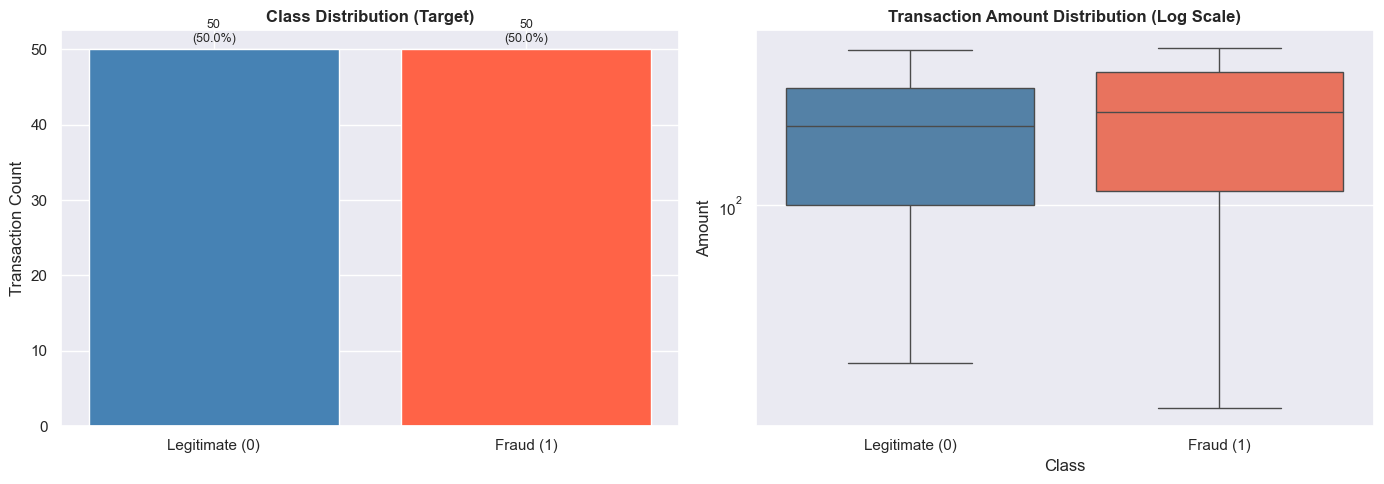

Total transactions: 100
Legitimate (Class 0): 50 (50.00%)
Fraudulent (Class 1): 50 (50.00%)


In [4]:
counts = df['Class'].value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Target class bar plot
axes[0].bar(
    ['Legitimate (0)', 'Fraud (1)'],
    counts.values,
    color=['steelblue', 'tomato'],
    edgecolor='white',
)
axes[0].set_title('Class Distribution (Target)', fontweight='bold')
axes[0].set_ylabel('Transaction Count')
for i, v in enumerate(counts.values):
    axes[0].text(
        i,
        v + len(df) * 0.01,
        f'{v:,}\n({v / len(df) * 100:.1f}%)',
        ha='center',
        fontsize=9,
    )

# Box plot of amount (assign hue to silence seaborn 0.13 deprecation)
sns.boxplot(
    data=df,
    x='Class',
    y='Amount',
    hue='Class',
    palette={0: 'steelblue', 1: 'tomato'},
    legend=False,
    ax=axes[1],
)
axes[1].set_yscale('log')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Legitimate (0)', 'Fraud (1)'])
axes[1].set_title('Transaction Amount Distribution (Log Scale)', fontweight='bold')
axes[1].set_ylabel('Amount')

plt.tight_layout()
os.makedirs('../reports', exist_ok=True)
plt.savefig('../reports/eda_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Total transactions: {len(df):,}')
print(f'Legitimate (Class 0): {counts.get(0, 0):,} ({counts.get(0, 0) / len(df) * 100:.2f}%)')
print(f'Fraudulent (Class 1): {counts.get(1, 0):,} ({counts.get(1, 0) / len(df) * 100:.2f}%)')

## 📊 5. EDA — Feature Correlations with Target

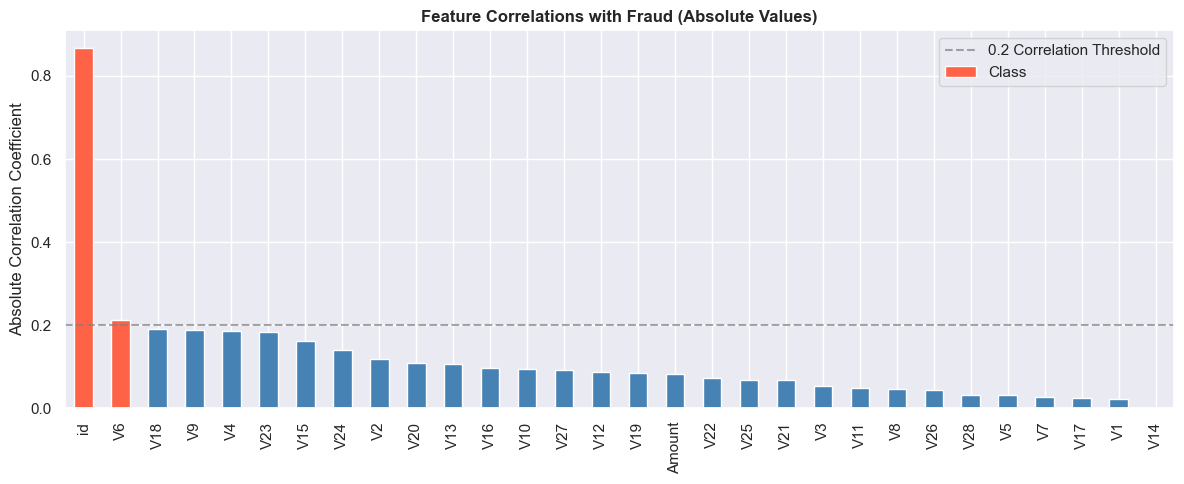

Top 10 correlated features:
id     0.866069
V6     0.213949
V18    0.191417
V9     0.189282
V4     0.186295
V23    0.183445
V15    0.163163
V24    0.140169
V2     0.119548
V20    0.109792
Name: Class, dtype: float64


In [5]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()['Class'].drop('Class').abs().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
colors = ['tomato' if v > 0.2 else 'steelblue' for v in corr.values]
corr.plot(kind='bar', color=colors, edgecolor='white')
plt.axhline(0.2, color='gray', linestyle='--', alpha=0.7, label='0.2 Correlation Threshold')
plt.title('Feature Correlations with Fraud (Absolute Values)', fontweight='bold')
plt.ylabel('Absolute Correlation Coefficient')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/eda_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 correlated features:')
print(corr.head(10))

## 🔬 6. EDA — Density Distribution of Top Correlated Features

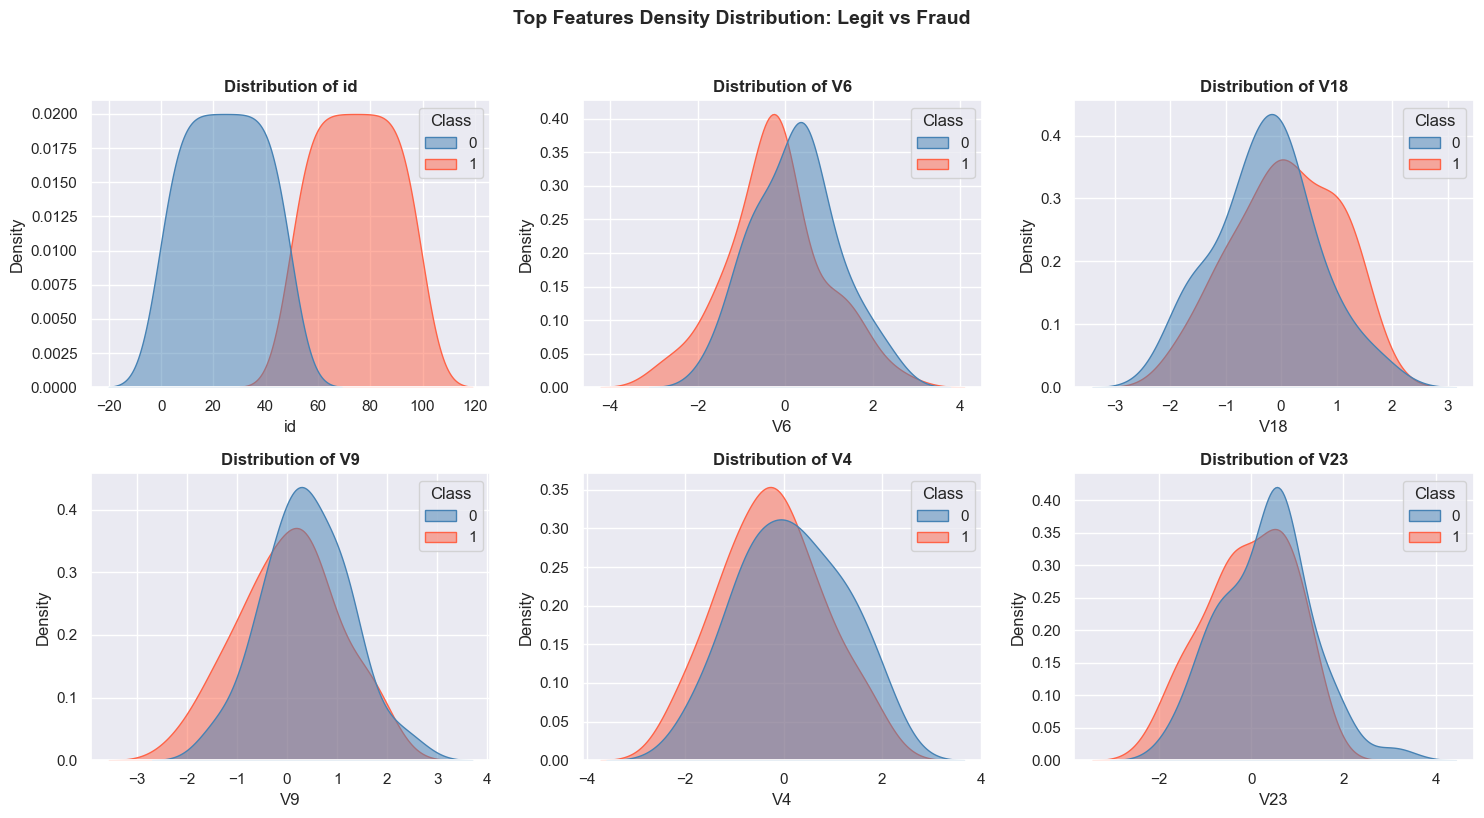

In [6]:
top_features = corr.head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    sns.kdeplot(
        data=df,
        x=feat,
        hue='Class',
        fill=True,
        common_norm=False,
        palette={0: 'steelblue', 1: 'tomato'},
        alpha=0.5,
        ax=axes[i],
    )
    axes[i].set_title(f'Distribution of {feat}', fontweight='bold')

plt.suptitle(
    'Top Features Density Distribution: Legit vs Fraud',
    fontsize=14,
    fontweight='bold',
    y=1.02,
)
plt.tight_layout()
plt.savefig('../reports/eda_top_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## ⚙️ 7. Preprocessing & Splitting
Drop the `id` column, stratify-split into train/test, and standardize the `Amount` feature.

In [7]:
df_model = df.drop(columns=['id']) if 'id' in df.columns else df.copy()

X = df_model.drop(columns=['Class'])
y = df_model['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled['Amount'] = scaler.fit_transform(X_train[['Amount']])
X_test_scaled['Amount'] = scaler.transform(X_test[['Amount']])

print(f'Training set: {X_train_scaled.shape} (fraud ratio: {y_train.mean():.4f})')
print(f'Testing set : {X_test_scaled.shape} (fraud ratio: {y_test.mean():.4f})')

Training set: (80, 29) (fraud ratio: 0.5000)
Testing set : (20, 29) (fraud ratio: 0.5000)


## 🚀 8. Hyperparameter Tuning with Optuna & MLflow
Each Optuna trial logs as a nested MLflow run under a parent study run.  
On large datasets we tune on a 20% subsample for speed; on small samples we use the full training set so each fold has enough rows.

In [8]:
# Adapt the tuning subset to dataset size: use full train for small datasets,
# 20% subsample when there is plenty of data.
if len(X_train_scaled) >= 5000:
    X_tune, _, y_tune, _ = train_test_split(
        X_train_scaled, y_train,
        train_size=0.2, stratify=y_train, random_state=RANDOM_STATE,
    )
    print(f'Tuning on 20% subsample: {X_tune.shape}')
else:
    X_tune, y_tune = X_train_scaled, y_train
    print(f'Tuning on full training set: {X_tune.shape}')


def _suggest_params(trial, model_name):
    if model_name == 'logistic_regression':
        return {
            'C': trial.suggest_float('C', 1e-4, 1e2, log=True),
            'solver': trial.suggest_categorical('solver', ['lbfgs', 'saga']),
            'max_iter': 1000,
        }
    if model_name == 'xgboost':
        return {
            'n_estimators': trial.suggest_int('n_estimators', 50, 150),
            'max_depth': trial.suggest_int('max_depth', 3, 7),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'eval_metric': 'logloss',
        }
    if model_name == 'lightgbm':
        return {
            'n_estimators': trial.suggest_int('n_estimators', 50, 150),
            'max_depth': trial.suggest_int('max_depth', 3, 7),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 8, 64),
            'verbosity': -1,
        }
    raise ValueError(f'Unknown model: {model_name}')


def _build_model(model_name, params):
    if model_name == 'logistic_regression':
        return LogisticRegression(**params, random_state=RANDOM_STATE)
    if model_name == 'xgboost':
        return XGBClassifier(**params, random_state=RANDOM_STATE, n_jobs=-1)
    if model_name == 'lightgbm':
        return LGBMClassifier(**params, random_state=RANDOM_STATE, n_jobs=-1)
    raise ValueError(f'Unknown model: {model_name}')


def run_optuna_tuning(model_name, n_trials=5):
    print(f'🏁 Starting Optuna tuning for {model_name}...')

    def objective(trial):
        with mlflow.start_run(run_name=f'{model_name}_trial_{trial.number}', nested=True):
            params = _suggest_params(trial, model_name)
            model = _build_model(model_name, params)

            X_tr, X_val, y_tr, y_val = train_test_split(
                X_tune, y_tune,
                test_size=0.25, stratify=y_tune, random_state=RANDOM_STATE,
            )
            model.fit(X_tr, y_tr)
            preds = model.predict(X_val)
            f1 = f1_score(y_val, preds, zero_division=0)

            mlflow.log_params(params)
            mlflow.log_metric('val_f1', f1)
            return f1

    with mlflow.start_run(run_name=f'{model_name}_optuna_study'):
        study = optuna.create_study(direction='maximize')
        study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
        mlflow.log_params(study.best_params)
        mlflow.log_metric('best_val_f1', study.best_value)
        print(f'✅ {model_name} tuning complete. Best F1={study.best_value:.5f}')
        print(f'   Best params: {study.best_params}\n')
        return study.best_params


best_params_lr = run_optuna_tuning('logistic_regression', n_trials=5)
best_params_xgb = run_optuna_tuning('xgboost', n_trials=5)
best_params_lgb = run_optuna_tuning('lightgbm', n_trials=5)

Tuning on full training set: (80, 29)
🏁 Starting Optuna tuning for logistic_regression...


🏃 View run logistic_regression_trial_0 at: https://dagshub.com/harshithnchandan/fraud-detection-mlops.mlflow/#/experiments/0/runs/8a96a57295744ce5a6a9831f86c3c767
🧪 View experiment at: https://dagshub.com/harshithnchandan/fraud-detection-mlops.mlflow/#/experiments/0


🏃 View run logistic_regression_trial_1 at: https://dagshub.com/harshithnchandan/fraud-detection-mlops.mlflow/#/experiments/0/runs/920338c6b9bb4696b1d75be676803156
🧪 View experiment at: https://dagshub.com/harshithnchandan/fraud-detection-mlops.mlflow/#/experiments/0


🏃 View run logistic_regression_trial_2 at: https://dagshub.com/harshithnchandan/fraud-detection-mlops.mlflow/#/experiments/0/runs/1600195383964fa8a84d69f9e92dae53
🧪 View experiment at: https://dagshub.com/harshithnchandan/fraud-detection-mlops.mlflow/#/experiments/0


🏃 View run logistic_regression_trial_3 at: https://dagshub.com/harshithnchandan/fraud-detection-mlops.mlflow/#/experiments/0/runs/9ec42c7163b143ff80e1b5ffc60fcc91
🧪 View experiment at: https://dagshub.com/harshithnchandan/fraud-detection-mlops.mlflow/#/experiments/0


...

🏃 View run lightgbm_trial_2 at: https://dagshub.com/harshithnchandan/fraud-detection-mlops.mlflow/#/experiments/0/runs/ed01527002974e498d2218d61f358366
🧪 View experiment at: https://dagshub.com/harshithnchandan/fraud-detection-mlops.mlflow/#/experiments/0


🏃 View run lightgbm_trial_3 at: https://dagshub.com/harshithnchandan/fraud-detection-mlops.mlflow/#/experiments/0/runs/4205106b0c364b55ae23670e7daa86ac
🧪 View experiment at: https://dagshub.com/harshithnchandan/fraud-detection-mlops.mlflow/#/experiments/0


🏃 View run lightgbm_trial_4 at: https://dagshub.com/harshithnchandan/fraud-detection-mlops.mlflow/#/experiments/0/runs/633e9cd3e2d94f81b39893d07297ef6b
🧪 View experiment at: https://dagshub.com/harshithnchandan/fraud-detection-mlops.mlflow/#/experiments/0


✅ lightgbm tuning complete. Best F1=0.55556
   Best params: {'n_estimators': 83, 'max_depth': 6, 'learning_rate': 0.09148179945942533, 'num_leaves': 14}



🏃 View run lightgbm_optuna_study at: https://dagshub.com/harshithnchandan/fraud-detection-mlops.mlflow/#/experiments/0/runs/1303804160d44a3480f29b9a626ed658
🧪 View experiment at: https://dagshub.com/harshithnchandan/fraud-detection-mlops.mlflow/#/experiments/0


## 🏆 9. Train and Track Final Models with Best Parameters

In [9]:
FINAL_RUN_IDS = {}
FINAL_MODEL_URIS = {}


def _log_flavor_model(model_name, model):
    """Log model with the right MLflow flavor and return its ModelInfo."""
    if model_name == 'logistic_regression':
        return mlflow.sklearn.log_model(model, name='model')
    if model_name == 'xgboost':
        return mlflow.xgboost.log_model(model, name='model')
    if model_name == 'lightgbm':
        return mlflow.lightgbm.log_model(model, name='model')
    raise ValueError(f'Unknown model: {model_name}')


def train_and_log_final_model(model_name, model, params):
    print(f'🚀 Training final {model_name}...')
    with mlflow.start_run(run_name=f'{model_name}_final') as run:
        mlflow.log_params(params)

        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
        if hasattr(model, 'predict_proba'):
            pred_probs = model.predict_proba(X_test_scaled)[:, 1]
        else:
            pred_probs = preds

        metrics = {
            'accuracy': accuracy_score(y_test, preds),
            'precision': precision_score(y_test, preds, zero_division=0),
            'recall': recall_score(y_test, preds, zero_division=0),
            'f1': f1_score(y_test, preds, zero_division=0),
            'roc_auc': roc_auc_score(y_test, pred_probs),
            'avg_precision': average_precision_score(y_test, pred_probs),
        }
        mlflow.log_metrics(metrics)

        model_info = _log_flavor_model(model_name, model)
        FINAL_RUN_IDS[model_name] = run.info.run_id
        FINAL_MODEL_URIS[model_name] = model_info.model_uri

        print(
            f"   F1={metrics['f1']:.5f} | ROC-AUC={metrics['roc_auc']:.5f} | "
            f"PR-AUC={metrics['avg_precision']:.5f}"
        )
        return metrics


final_lr = LogisticRegression(**best_params_lr, random_state=RANDOM_STATE, max_iter=1000)
final_xgb = XGBClassifier(**best_params_xgb, random_state=RANDOM_STATE, n_jobs=-1)
final_lgb = LGBMClassifier(**best_params_lgb, random_state=RANDOM_STATE, n_jobs=-1)

results = {
    'logistic_regression': train_and_log_final_model('logistic_regression', final_lr, best_params_lr),
    'xgboost': train_and_log_final_model('xgboost', final_xgb, best_params_xgb),
    'lightgbm': train_and_log_final_model('lightgbm', final_lgb, best_params_lgb),
}

🚀 Training final logistic_regression...


2026/05/21 22:36:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


   F1=0.44444 | ROC-AUC=0.48000 | PR-AUC=0.67818


🏃 View run logistic_regression_final at: https://dagshub.com/harshithnchandan/fraud-detection-mlops.mlflow/#/experiments/0/runs/6300cab023bb46bd8d3941ab403b26de
🧪 View experiment at: https://dagshub.com/harshithnchandan/fraud-detection-mlops.mlflow/#/experiments/0


🚀 Training final xgboost...


...

🏃 View run xgboost_final at: https://dagshub.com/harshithnchandan/fraud-detection-mlops.mlflow/#/experiments/0/runs/c20f41ec249342429f8c76634a17f447
🧪 View experiment at: https://dagshub.com/harshithnchandan/fraud-detection-mlops.mlflow/#/experiments/0


🚀 Training final lightgbm...


2026/05/21 22:37:10 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


   F1=0.44444 | ROC-AUC=0.50000 | PR-AUC=0.63142


🏃 View run lightgbm_final at: https://dagshub.com/harshithnchandan/fraud-detection-mlops.mlflow/#/experiments/0/runs/be85de3c79944d0396e05bd080901255
🧪 View experiment at: https://dagshub.com/harshithnchandan/fraud-detection-mlops.mlflow/#/experiments/0


## 📊 10. Compare & Register Best Model

📊 Model Comparison Table:


,accuracy,precision,recall,f1,roc_auc,avg_precision
logistic_regression,0.50000,0.50000,0.40000,0.44444,0.48000,0.67818
xgboost,0.45000,0.44444,0.40000,0.42105,0.50000,0.62339
lightgbm,0.50000,0.50000,0.40000,0.44444,0.50000,0.63142


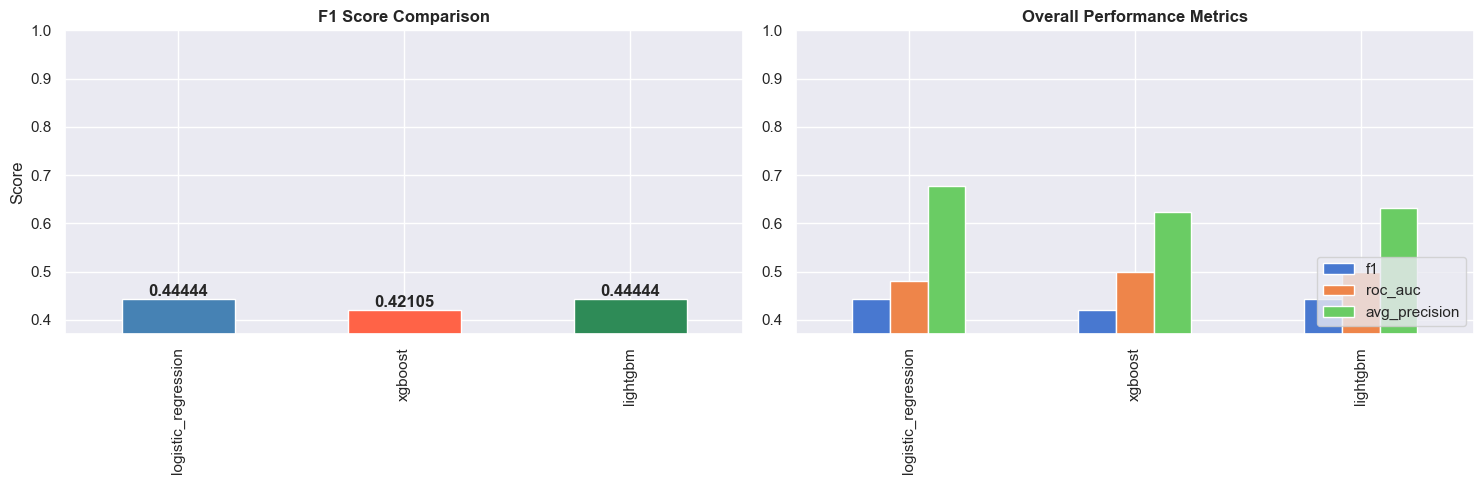

✅ Plot saved to: ../reports/model_comparison.png
🏆 Best model: LOGISTIC_REGRESSION | F1-Score: 0.44444

📦 Registering model from: models:/m-78c88f24a63745a3b7204ebb66e9d62d


Registered model 'fraud-detection-champion' already exists. Creating a new version of this model...


2026/05/21 22:37:27 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: fraud-detection-champion, version 1


Created version '1' of model 'fraud-detection-champion'.


✅ Successfully registered version 1
🔗 View model: https://dagshub.com/harshithnchandan/fraud-detection-mlops.mlflow/#/models


In [10]:
os.makedirs('../reports', exist_ok=True)

results_df = pd.DataFrame(results).T
print('📊 Model Comparison Table:')
try:
    display(
        results_df.style
        .highlight_max(color='lightgreen', axis=0)
        .format('{:.5f}')
    )
except Exception:
    print(results_df.round(5))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

results_df['f1'].plot(
    kind='bar',
    ax=axes[0],
    color=['steelblue', 'tomato', 'seagreen'],
    edgecolor='white',
)
axes[0].set_title('F1 Score Comparison', fontweight='bold')
axes[0].set_ylabel('Score')
y_min = max(0.0, results_df['f1'].min() - 0.05)
axes[0].set_ylim(y_min, 1.0)
for i, v in enumerate(results_df['f1']):
    axes[0].text(i, v + 0.005, f'{v:.5f}', ha='center', fontweight='bold')

results_df[['f1', 'roc_auc', 'avg_precision']].plot(
    kind='bar',
    ax=axes[1],
    edgecolor='white',
)
axes[1].set_title('Overall Performance Metrics', fontweight='bold')
axes[1].set_ylim(y_min, 1.0)
axes[1].legend(loc='lower right')

plt.tight_layout()
plot_path = '../reports/model_comparison.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Plot saved to: {plot_path}')

best_model_name = results_df['f1'].idxmax()
print(
    f"🏆 Best model: {best_model_name.upper()} | "
    f"F1-Score: {results_df.loc[best_model_name, 'f1']:.5f}"
)

# Register the best model. Use the model URI captured from log_model so it
# works on both legacy `runs:/` and the new MLflow logged-model URIs.
best_model_uri = FINAL_MODEL_URIS.get(best_model_name)
if best_model_uri is None:
    print('⚠️ No captured model URI for the best model, skipping registration.')
else:
    print(f'\n📦 Registering model from: {best_model_uri}')
    try:
        model_details = mlflow.register_model(
            model_uri=best_model_uri,
            name=REGISTERED_MODEL_NAME,
        )
        print(f'✅ Successfully registered version {model_details.version}')
        if USING_DAGSHUB:
            print(
                f'🔗 View model: '
                f'https://dagshub.com/{DAGSHUB_USERNAME}/{DAGSHUB_REPO}.mlflow/#/models'
            )
    except Exception as exc:
        print(f'❌ Model registration failed: {exc}')